---
title: CONUS404 — Monthly precipitation across CONUS
author: Harsha R. Hampapura
date: 2026-05-28
---

## Monthly precipitation across the contiguous US (CONUS404)

This notebook illustrates how to make diagnostic plots using the **CONUS404**
dataset hosted on NCAR's [Geoscience Data Exchange (GDEX)](https://gdex.ucar.edu/datasets/d559000/).

[CONUS404](https://gdex.ucar.edu/datasets/d559000/) is a 4-km, hourly, 43-year
hydroclimate reanalysis of the contiguous United States, produced by NCAR and
the USGS by dynamically downscaling ERA5 with the Weather Research and
Forecasting (WRF) model in a *convection-permitting* configuration. The
dataset is described in [Rasmussen et al. (2023, BAMS)](https://journals.ametsoc.org/view/journals/bams/104/8/BAMS-D-21-0326.1.xml).

The native data are hourly NetCDF files — roughly **377,000 files** for the
full 1979–2022 record — which would be awkward to stream individually. GDEX
provides a [kerchunk](https://fsspec.github.io/kerchunk/) reference layer on
top of those NetCDFs that exposes the entire record as a single virtual
`xarray.Dataset`. With it, we can slice 43 years of 4-km hourly data using a single xarray call and only stream the bytes we actually need.

## What this notebook does

Using one calendar year of CONUS404, we produce a **12-panel map of monthly
precipitation totals over CONUS**. This is a scaled-down version of Figure 3
in Rasmussen et al. (2023), which averages 35 water years to build the
published climatology. Here we focus on a single year so the workflow stays
tractable and the seasonal march of precipitation across the country is
visible in one figure.

In [1]:
# Imports 
import intake
import numpy as np
import pandas as pd
import xarray as xr
import seaborn as sns
import matplotlib.pyplot as plt
import os
import cartopy.crs as ccrs
import cartopy.feature as cfeature
import cmap                              
from matplotlib.colors import BoundaryNorm
from cmap import Colormap

# Dask imports
import dask 
from dask_jobqueue import PBSCluster
from dask.distributed import Client

In [2]:
# Catalog URLs
cat_url     = 'https://data.gdex.ucar.edu/d559000/catalogs/d559000-https.json' # HTTPS access
print(cat_url)

https://data.gdex.ucar.edu/d559000/catalogs/d559000-https.json


In [3]:
# Set up your scratch folder path
username       = os.environ["USER"]
glade_scratch  = "/glade/derecho/scratch/" + username
print(glade_scratch)

/glade/derecho/scratch/harshah


## Create a PBS cluster

In [4]:
# Create a PBS cluster object
cluster = PBSCluster(
    job_name        = "conus404-precip",
    cores           = 1,
    memory          = "4GiB",
    processes       = 1,
    local_directory = f"{glade_scratch}/dask/spill/",
    log_directory   = f"{glade_scratch}/dask/logs/",
    resource_spec   = "select=1:ncpus=1:mem=4GB",
    queue           = "casper",
    walltime        = "1:00:00",
    interface       = "ext",)

# Scale the cluster and display cluster dashboard URL
n_workers = 12
client = Client(cluster)
cluster.scale(n_workers)
client.wait_for_workers(n_workers=n_workers)
cluster

PBSCluster(c5891af3, 'tcp://128.117.208.97:46717', workers=12, threads=12, memory=48.00 GiB)

## Load CONUS 404 data from GDEX using an intake catalog

In [5]:
col = intake.open_esm_datastore(cat_url)
col

,unique
path,2
variable,206
format,1
short_name,206
long_name,214
units,31
start_time,1
end_time,1
level,1
level_units,1


- col.df turns the catalog object into a pandas dataframe!
- (Actually, it accesses the dataframe attribute of the catalog)

## Select data and plot

#### What if you don't know the variable names ?
- Use pandas logic to print out the short_name and long_name

In [6]:
col.df[['variable','long_name']]

,variable,long_name
0,ACDEWC,"Accumulated canopy dew rate, accumulated over ..."
1,ACDRIPR,"Accumulated canopy precipitation drip rate, ac..."
2,ACDRIPS,"Accumulated canopy snow drip rate, accumulated..."
3,ACECAN,Accumulated net evaporation of canopy water (e...
4,ACEDIR,Accumulated net soil evaporation or snowpack s...
...,...,...
210,V,V-component of wind with respect to model grid
211,W,W-component of wind
212,Z,Geopotential height (PH + PHB)/9.81
213,ilev,vertical stagger levels


:::{tip} Do you know that the wrfout data doctionary lists all the variables and their long names ?
- The wrfout_datadictionary can be found [here](https://gdex.ucar.edu/datasets/d559000/documentation/#)

### Find the precipitation variable in the catalog

CONUS404 WRF output stores grid-scale accumulated precipitation per hourly
output step as `PREC_ACC_NC` (units: mm). Because the output step is hourly,
this is also the hourly precipitation rate in mm hr⁻¹.

In [7]:
# Sanity check — list precip-like variables present in the catalog
precip_like = col.df[col.df["variable"].str.contains("PREC|RAIN", case=False, na=False)]
precip_like[["variable", "long_name"]].drop_duplicates()

,variable,long_name
40,ACRAINLSM,Accumulated liquid precipitation into land sur...
41,ACRAINSNOW,"Acccumlated rain on snow pack, accumulated ove..."
118,PREC_ACC_NC,"Accumulated grid scale precipitation , accumu..."
127,RAINNCV,TIME-STEP NONCONVECTIVE PRECIPITATION
202,QNRAIN,Rain Number concentration
203,QRAIN,Rain water mixing ratio


In [8]:
# Search the catalog for our variable of interest and inspect the paths.
cat_pr = col.search(variable="PREC_ACC_NC")
kerchunk_url = cat_pr.df["path"].iloc[0]
print('kerchunk url is :', kerchunk_url)

kerchunk url is : https://data.gdex.ucar.edu/d559000/kerchunk/wrf2d-remote-https.parq


### Choosing how to access CONUS404

CONUS404 is published as **hourly NetCDF files** — one file per hour, roughly
377,000 files for the full 1979–2022 record. Streaming hundreds of thousands
of small files over the network would be slow and brittle.

**GDEX adds a [kerchunk](https://fsspec.github.io/kerchunk/) reference layer**
on top of those NetCDFs. A kerchunk reference is a small parquet file that
tells `xarray` which byte range of which NetCDF holds each chunk. From the
reader's perspective it looks like a single virtual `xarray.Dataset`, and you
only stream the bytes you actually request.

GDEX publishes two such references for CONUS404, aggregating across **all
water years** and **all variables** in each group:

| File                         | Coverage |
|------------------------------|----------|
| `wrf2d-remote-https.parq`    | All **2D** variables — precipitation, 2-m temperature, surface energy fluxes, snow water equivalent, … |
| `wrf3d-remote-https.parq`    | All **3D** variables — temperature, humidity, wind on model levels |

We want hourly precipitation (`PREC_ACC_NC`), which is a 2D variable, so we
pick the `wrf2d` reference from the catalog paths returned in the previous
cell and open it with `xarray`'s kerchunk engine. The result is the full
43-year hourly record of every 2D variable in a single Dataset — ready to
slice with `.sel(Time=...)`.

:::{tip} Why use the kerchunk layer
It turns 377,000 NetCDF files into one virtual store and lets you read only
the chunks that overlap your time/space selection — no per-water-year loop,
no manual file concatenation.
:::

### Load data into xarray

In [9]:
%%time
# One kerchunk reference → 43 years of hourly 2D output.
# First open is slow (~15 s) because kerchunk parses the parquet index; subsequent slicing is fast and lazy.
ds = xr.open_dataset(kerchunk_url, engine="kerchunk")

pr    = ds["PREC_ACC_NC"]          # (Time: 376944, south_north: 1015, west_east: 1367)
lat2d = ds["XLAT"].isel(Time=0)    # 2D static lat/lon for plotting + masking
lon2d = ds["XLONG"].isel(Time=0)
pr

CPU times: user 10.8 s, sys: 1.45 s, total: 12.3 s
Wall time: 13.5 s


<xarray.DataArray 'PREC_ACC_NC' (Time: 376944, south_north: 1015,
                                 west_east: 1367)> Size: 2TB
[523011684720 values with dtype=float32]
Coordinates:
  * Time     (Time) datetime64[ns] 3MB 1979-10-01 ... 2022-09-30T23:00:00
    XTIME    (Time) datetime64[ns] 3MB ...
    XLAT     (Time, south_north, west_east) float32 2TB ...
    XLONG    (Time, south_north, west_east) float32 2TB ...
Dimensions without coordinates: south_north, west_east
Attributes:
    description:  ACCUMULATED GRID SCALE  PRECIPITATION OVER prec_acc_dt PERI...
    units:        mm
    stagger:       
    long_name:    Accumulated grid scale  precipitation , accumulated over pr...

## Data Analysis

### Part A: Monthly precipitation climatology

We sum hourly precipitation to monthly totals over WY 2020 and lay them out as
a 12-panel map. This is *one* water year — Fig. 3 of Rasmussen et al. (2023)
averages 35 water years. To reproduce the published climatology, loop this
reduction over water years 1986–2020 and average.

In [10]:
%%time
# Slice to calendar year 2020 — xarray accepts partial date strings.
pr_2020 = pr.sel(Time="2020")

# Monthly totals — 12 groups over an already-in-cluster array.
pr_monthly = pr_2020.groupby("Time.month").sum()
pr_monthly

CPU times: user 1.71 s, sys: 61.6 ms, total: 1.77 s
Wall time: 1.76 s


<xarray.DataArray 'PREC_ACC_NC' (month: 12, south_north: 1015, west_east: 1367)> Size: 67MB
dask.array<stack, shape=(12, 1015, 1367), dtype=float32, chunksize=(1, 882, 1188), chunktype=numpy.ndarray>
Coordinates:
  * month    (month) int64 96B 1 2 3 4 5 6 7 8 9 10 11 12
Dimensions without coordinates: south_north, west_east
Attributes:
    description:  ACCUMULATED GRID SCALE  PRECIPITATION OVER prec_acc_dt PERI...
    units:        mm
    stagger:       
    long_name:    Accumulated grid scale  precipitation , accumulated over pr...

### Compute the monthly totals and plot

The next cell triggers the reduction: streaming hourly precipitation chunks
from GDEX for all of 2020 and summing into 12 monthly grids.

:::{important} Expected runtime and transient failures
On a Casper PBS cluster with **12 workers × 4 GiB**, this cell takes
**~ 10 minutes** end to end — it streams roughly 50 GB of byte-range
requests from GDEX over HTTPS.

If the cell errors out with a `ReferenceNotReachable` traceback (a GDEX
HTTPS hiccup on one of the underlying NetCDF files), **just re-run the
cell**. These failures are almost always transient and a retry usually
succeeds.
:::

In [11]:
%%time
# Materialize once: 12 × 1015 × 1367 float32 ≈ 65 MB, fits comfortably.
pr_monthly_local = pr_monthly.compute()

# Cartopy projections: CONUS404 sits on a Lambert Conformal grid.
proj  = ccrs.LambertConformal(central_longitude=-97.5, central_latitude=38.5)
trans = ccrs.PlateCarree()

CPU times: user 2min 32s, sys: 6.83 s, total: 2min 39s
Wall time: 10min 42s


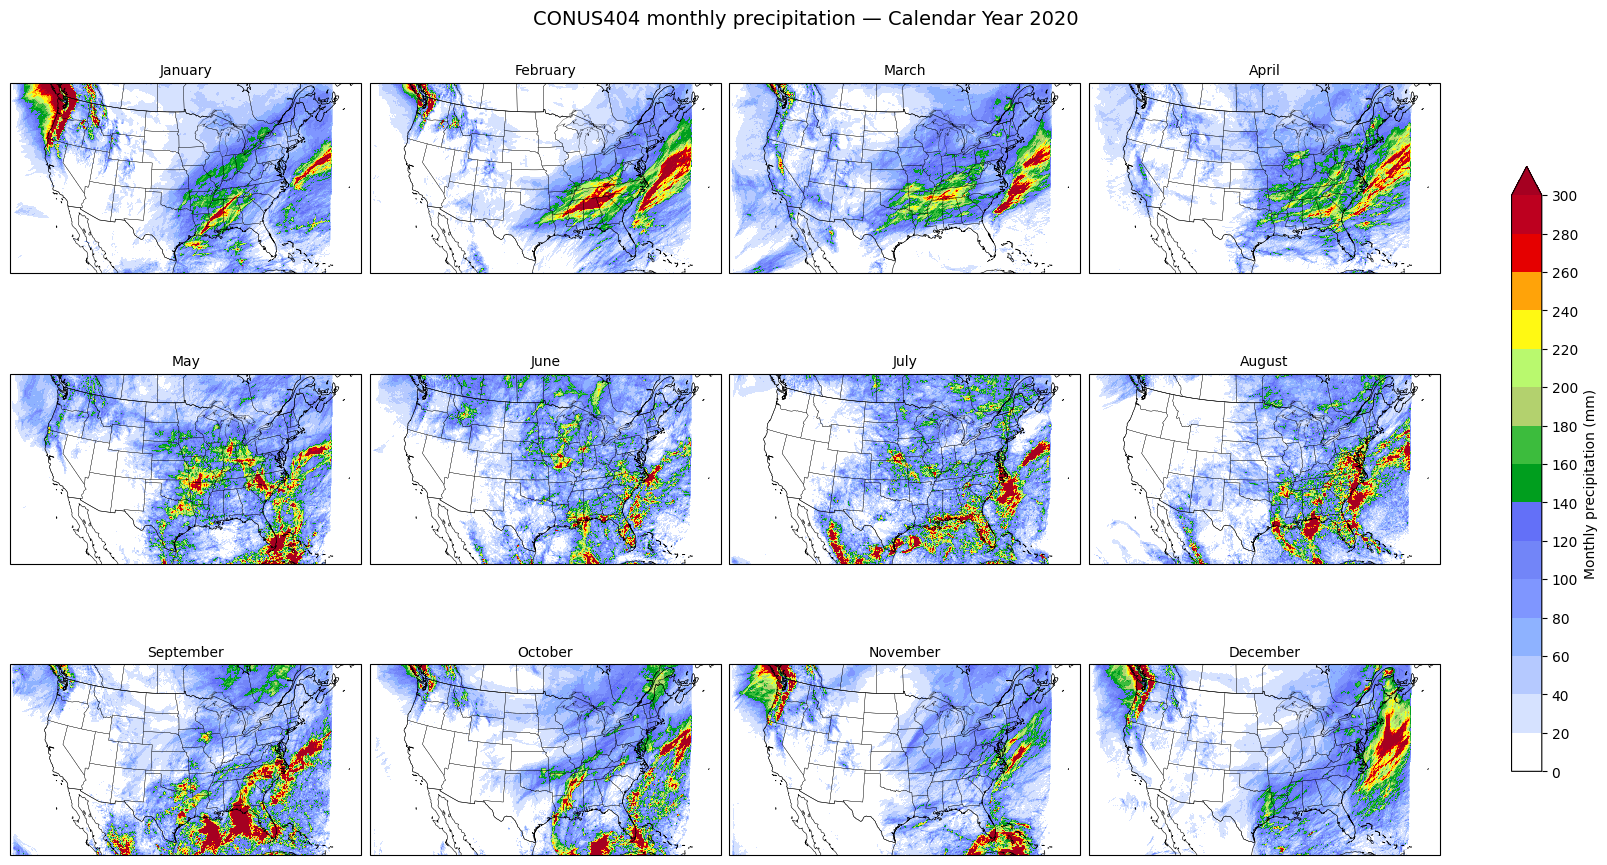

CPU times: user 28.1 s, sys: 1.2 s, total: 29.4 s
Wall time: 1min 1s


In [12]:
%%time
import calendar
from matplotlib.colors import ListedColormap, BoundaryNorm

# Colormap matched to Rasmussen et al. (2023) Fig. 4(a): NCL precip3_16lev (RGB 0–255)
_rgb255 = [
    (255,255,255), (214,226,255), (181,201,255), (142,178,255),
    (127,150,255), (114,133,248), ( 99,112,248), (  0,158, 30),
    ( 60,188, 61), (179,209,110), (185,249,110), (255,249, 19),
    (255,163,  9), (229,  0,  0), (189,  0, 31), (165,  0, 33),
]
cmap_pr = ListedColormap(np.array(_rgb255) / 255, name="precip3_16lev")
levels  = np.arange(0, 301, 20)                       # 0, 20, …, 300 mm
norm    = BoundaryNorm(levels, ncolors=cmap_pr.N, extend="max")

# Coarsen by 4× for plotting only (~16× fewer cells; saves cartopy memory)
COARSEN  = 4
pr_plot  = pr_monthly_local.coarsen(south_north=COARSEN, west_east=COARSEN, boundary="trim").mean()
lat_plot = lat2d.coarsen(south_north=COARSEN, west_east=COARSEN, boundary="trim").mean()
lon_plot = lon2d.coarsen(south_north=COARSEN, west_east=COARSEN, boundary="trim").mean()

fig, axes = plt.subplots(
    3, 4, figsize=(16, 9),
    subplot_kw={"projection": proj},
    constrained_layout=True,
)

for i, ax in enumerate(axes.flat):
    month_int = int(pr_plot.month.values[i])
    im = ax.pcolormesh(
        lon_plot.values, lat_plot.values, pr_plot.isel(month=i).values,
        transform=trans, cmap=cmap_pr, norm=norm, shading="auto",
    )
    ax.add_feature(cfeature.COASTLINE, lw=0.4)
    ax.add_feature(cfeature.BORDERS, lw=0.4)
    ax.add_feature(cfeature.STATES, lw=0.2)
    ax.set_extent([-125, -66, 24, 50], crs=trans)
    ax.set_title(calendar.month_name[month_int], fontsize=10)

cbar = fig.colorbar(
    im, ax=axes, shrink=0.7, orientation="vertical",
    ticks=levels, extend="max",
    label="Monthly precipitation (mm)",
)
fig.suptitle("CONUS404 monthly precipitation — Calendar Year 2020", fontsize=14)
plt.show()

In [14]:
cluster.close()